# Custom State
Node(Agent)간에 공유되는 상태정보를 커스터마이징할수 있다.

**최신 장소정보 공유**
- tool 장소검색api: naver/kakao/google map api(키워드 검색기반)
- tool 자연어 -> 검색을 위한 키워드추출
    - 나 여기 독산동인데, 여기 괜찮은 까페 추천해줘 -> 독산동 까페

In [10]:
from dotenv import load_dotenv
import os

load_dotenv()
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')
KAKAO_API_KEY = os.getenv('KAKAO_API_KEY')

os.environ['LANGSMITH_TRACING'] = 'true'
os.environ['LANGSMITH_ENDPOINT'] = 'https://apac.api.smith.langchain.com'
os.environ['LANGSMITH_PROJECT'] = 'skn34-langchain'
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')

## 카카오 장소검색 도구

https://developers.kakao.com/docs/latest/ko/local/dev-guide#search-by-keyword

In [ ]:
from langchain.tools import tool  # Tool 데코레이터
import requests  # http (rest-api) 요청 처리
from pprint import pprint
from typing import List, TypedDict  # 타입 힌트

class KakaoPlace(TypedDict):
    name: str
    address: str
    url: str

# 키워드를 이용해 카카오 장소 검색을 수행하는 툴
@tool
def kakao_place_search(query: str) -> List[KakaoPlace]:
    """
    카카오 장소검색 API를 호출하기 위한 도구

    Args:
        query: 검색어(키워드 기반)
    Returns:
        검색 결과
    """
    url = 'https://dapi.kakao.com/v2/local/search/keyword.json'
    headers = {
        'Authorization': f'KakaoAK {KAKAO_API_KEY}'
    }
    params = {'query': query, 'size': 5}  # 최대 5개 검색
    response = requests.get(url, headers=headers, params=params)  # API 호출
    data = response.json()  # JSON -> Python dict
    data = data['documents']  # 장소 목록

    return [
        {
            'name': place['place_name'],
            'address': place['address_name'],
            'url': place['place_url']
        } for place in data
    ]  # 리스트 안의 딕셔너리 형태.

pprint(kakao_place_search.invoke({'query': '독산동 맛집'}))

[{'address': '서울 금천구 독산동 163-2',
  'name': '왕래성',
  'url': 'http://place.map.kakao.com/538642507'},
 {'address': '서울 금천구 독산동 179-8',
  'name': '청정회센터',
  'url': 'http://place.map.kakao.com/9965001'},
 {'address': '서울 금천구 독산동 288-9',
  'name': '불맛전문관사부간짬뽕 독산직영점',
  'url': 'http://place.map.kakao.com/962610671'},
 {'address': '서울 금천구 독산동 1113',
  'name': '소하떡집',
  'url': 'http://place.map.kakao.com/1448413740'},
 {'address': '서울 금천구 독산동 378-428',
  'name': '돈유창',
  'url': 'http://place.map.kakao.com/1002142708'}]


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


### 키워드 추출 도구

In [9]:
from langchain.chat_models import init_chat_model
from langchain_core.prompts import PromptTemplate

llm = init_chat_model('gpt-5.4-mini')

@tool
def extract_keyword(user_request: str) -> str:
    """
    사용자 요청에서 장소검색API를 사용하기 위한 짧고 명확한 키워드를 추출하는 도구
    장소검색도구(kakao_place_search)를 사용하기 전에 사용자의 요청을 먼저 변환하세요.
    """

    prompt = PromptTemplate.from_template('''
    당신은 사용자의 요청을 장소검색에 필요한 키워드로 변환하는 전문가입니다.
    장문의 사용자 요청에서 키워드를 한 문장으로 추출해주세요.
    - 키워드는 띄워쓰기로 구분된 한 문장이어야 합니다.
    - 다른 설명은 하지 말고, 키워드만 추출합니다.

    [사용자요청]
    {user_request}


    [예시]
    - 여기 독산동인데, 소문난 맛집좀 알려줘봐 -> 독산동 맛집
    - 부산 핫플 좀 알려줘봐 -> 부산 맛집

    [금지어]
    - 소문난
    - 핫플
    ''')

    chain = prompt | llm
    response = chain.invoke({'user_request': user_request})
    return response.content.strip().strip('"').strip("'")

print(extract_keyword.invoke('제주도 애월 맛집 리스트 뽑아줘'))
print(extract_keyword.invoke('부산 기장쪽의 맛집 알려줘'))
print(extract_keyword.invoke('용인 명지대역쪽 맛있고 분위기 좋은 식당 알려줘'))
print(extract_keyword.invoke('산본 곡란중학교쪽 카페 추천해줘'))
print(extract_keyword.invoke('용산역에서 할만하거나 갈만한 곳 알려줘'))

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


제주도 애월 맛집


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


부산 기장 맛집


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


...

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


산본 곡란중학교 카페


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


용산역 갈만한 곳


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


### 그래프 구성
- 키워드 추출 -> 카카오 장소 검색 -> 상태(State)에 결과를 저장하는 Langgraph

In [ ]:
from langgraph.graph import StateGraph, START, END  # 그래프 구성 요소
from langgraph.prebuilt import ToolNode, tools_condition  # 도구 노드, 분기 조건
from typing import Annotated, Optional  # 타입 힌트 도구
from langgraph.graph.message import add_messages  # 메시지 누적 처리를 해줄 헬퍼
from langchain_core.messages import BaseMessage, ToolMessage  # 메시지 타입

# 그래프에서 사용할 상태(TypedDict) 스키마
class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]  # messages 필드 리스트를 add_messages 규칙으로 누적 저장 
    search_query: Optional[str]  # 검색 키워드
    search_results: Optional[List[KakaoPlace]]   # 장소 검색 결과

llm = init_chat_model('gpt-5.4-mini')
tools = [kakao_place_search, extract_keyword]
llm_with_tools = llm.bind_tools(tools)  # llm에 도구 스펙 바인딩

# State의 messages를 입력으로 받아, 응답 메시지를 추가해주는 노드 함수
def chatbot(state: State):
    if isinstance(state['messages'][-1], ToolMessage):  # 직전 도구 실행을 한 경우
        if state['messages'][-1].name == 'extract_keyword':  # 키워드 추출 도구면
            state['search_query'] = state['messages'][-1].content  # 검색 키워드 저장
        elif state['messages'][-1].name == 'kakao_place_search':  # 장소 검색 추출 도구면
            state['search_results'] = state['messages'][-1].content  # 검색 결과 저장

    response = llm_with_tools.invoke(state['messages'])  # 누적된 메시지 리스트로 LLM 호출
    return {**state, 'messages': [response]}  # state 상태 유지 + 새 응답 메시지 누적 반환

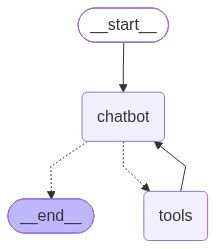

In [12]:
# langgraph.prebuilt 모듈의 ToolNode와 tools_condition 함수 사용한 빌더
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

builder = StateGraph(State)  # State 스키마 기반 그래프 설계 객체 생성
tool_node = ToolNode(tools)

builder.add_edge(START, 'chatbot')   # 시작 노드 -> chatbot 노드

builder.add_node('chatbot', chatbot)  # chatbot 노드
builder.add_node('tools', tool_node)  # tools 노드

builder.add_conditional_edges('chatbot', tools_condition)
builder.add_edge('tools', 'chatbot')

graph = builder.compile()  # 그래프 컴파일

graph  # 그래프 객체

### 그래프 실행

In [ ]:
# 그래프 실행 초기상태
initial_state: State = {
    'messages': [('human', '독산역 맛집 알려줘')],
    'search_query': None,
    'search_results': None
}

final_state = graph.invoke(initial_state)  # 그래프 실행 : 키워드 추출 -> 장소 검색 -> 응답 생성
final_state

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/ru

{'messages': [HumanMessage(content='독산역 맛집 알려줘', additional_kwargs={}, response_metadata={}, id='b2bb5539-ef80-4143-9a5f-3844bb93e2e5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 219, 'total_tokens': 243, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0, 'text_tokens': None}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0, 'image_tokens': None, 'text_tokens': None}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EJw607TPCEEf3HsUM9PNpzRqLHzeH', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--01a06627-7c15-7292-a1da-59301b7341c4-0', tool_calls=[{'name': 'extract_keyword', 'args': {'user_request': '독산역 맛집 알려줘'}, 'id': 'call_XG033A05STkmdjHVzi18NVJR', 'type':

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [ ]:
from IPython.display import Markdown  #Jupyter - Markdown 랜더링

Markdown(final_state['messages'][-1].content)  # 마지막 메시지 마크다운 형식 출력

독산역 근처 맛집으로 몇 곳 찾아봤어요.

- 도원 — 서울 금천구 가산동 685  
  http://place.map.kakao.com/1713311171
- 다온푸드 — 서울 금천구 가산동 673  
  http://place.map.kakao.com/1730488332
- 모리스시 — 서울 금천구 가산동 673  
  http://place.map.kakao.com/1777821112
- 칼포니치킨&호프 독산역점 — 서울 금천구 독산동 1006-23  
  http://place.map.kakao.com/16767884
- 태우마 본점 — 서울 금천구 독산동 1142  
  http://place.map.kakao.com/2037687026

원하시면 제가 여기서
1) 한식 위주  
2) 술집/회식  
3) 혼밥  
4) 점심 가성비  
로 나눠서 다시 골라드릴게요.

### 그래프 디버깅

In [16]:
for msg in final_state['messages']:
    msg.pretty_print()  # 보기좋은 형식으로 출력

================================ Human Message =================================

독산역 맛집 알려줘
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_XG033A05STkmdjHVzi18NVJR)
 Call ID: call_XG033A05STkmdjHVzi18NVJR
  Args:
    user_request: 독산역 맛집 알려줘
================================= Tool Message =================================
Name: extract_keyword

독산역 맛집
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_5B9fvj1H2p8HMqkjaLvUGZSH)
 Call ID: call_5B9fvj1H2p8HMqkjaLvUGZSH
  Args:
    query: 독산역 맛집
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "도원", "address": "서울 금천구 가산동 685", "url": "http://place.map.kakao.com/1713311171"}, {"name": "다온푸드", "address": "서울 금천구 가산동 673", "url": "http://place.map.kakao.com/1730488332"}, {"name": "모리스시", "address": "서울 금천구 가산동 673", "url": "http://place.m

In [ ]:
# Langgraph 스트리밍 실행 : 노드별 실행 결과를 실시간 확인
initial_state: State = {
    'messages': [('human', '제주 애월의 맛집 알려줘')],
    'search_query': None,
    'search_results': None
}

# 그래프를 스트리밍 방식으로 실행 (stream_mode='updates' : 기본값.  => 실행 중단마다 결과 전달.)
for chunk in graph.stream(initial_state, stream_mode='updates'):  # 그래프 실행 : 키워드 추출 -> 장소 검색 -> 응답 생성
    for node, update in chunk.items():  # (실행된 노드, 해당 업데이트)
        print(f'{node} node')
        update['messages'][-1].pretty_print()  # 해당 노드에 추가된 마지막 메시지
    print()

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


chatbot node
================================== Ai Message ==================================
Tool Calls:
  extract_keyword (call_7WlYui3dHWWoYa9x2Xd0GduO)
 Call ID: call_7WlYui3dHWWoYa9x2Xd0GduO
  Args:
    user_request: 제주 애월의 맛집 알려줘



Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


tools node
================================= Tool Message =================================
Name: extract_keyword

제주 애월 맛집



Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


chatbot node
================================== Ai Message ==================================
Tool Calls:
  kakao_place_search (call_bgTH8CMVyrTdplnqTAcAJQaM)
 Call ID: call_bgTH8CMVyrTdplnqTAcAJQaM
  Args:
    query: 제주 애월 맛집

tools node
================================= Tool Message =================================
Name: kakao_place_search

[{"name": "애월남도한상", "address": "제주특별자치도 제주시 애월읍 구엄리 857-1", "url": "http://place.map.kakao.com/2020988732"}, {"name": "하르방짬뽕", "address": "제주특별자치도 제주시 애월읍 하귀1리 214-4", "url": "http://place.map.kakao.com/823098366"}, {"name": "바다속고등어쌈밥", "address": "제주특별자치도 제주시 애월읍 하귀1리 1548", "url": "http://place.map.kakao.com/20733624"}, {"name": "소길다방", "address": "제주특별자치도 제주시 애월읍 소길리 619", "url": "http://place.map.kakao.com/2032708564"}, {"name": "도치돌가든", "address": "제주특별자치도 제주시 애월읍 어음리 2472-1", "url": "http://place.map.kakao.com/10309237"}]



Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


chatbot node
================================== Ai Message ==================================

제주 애월에서 찾은 맛집 몇 곳 알려드릴게요.

1. **애월남도한상**  
   - 제주특별자치도 제주시 애월읍 구엄리 857-1  
   - http://place.map.kakao.com/2020988732

2. **하르방짬뽕**  
   - 제주특별자치도 제주시 애월읍 하귀1리 214-4  
   - http://place.map.kakao.com/823098366

3. **바다속고등어쌈밥**  
   - 제주특별자치도 제주시 애월읍 하귀1리 1548  
   - http://place.map.kakao.com/20733624

4. **소길다방**  
   - 제주특별자치도 제주시 애월읍 소길리 619  
   - http://place.map.kakao.com/2032708564

5. **도치돌가든**  
   - 제주특별자치도 제주시 애월읍 어음리 2472-1  
   - http://place.map.kakao.com/10309237

원하시면 제가  
- **한식/해산물/고기/카페**로 나눠서 추천하거나  
- **현지인 스타일, 분위기 좋은 곳, 아이와 가기 좋은 곳** 기준으로도 골라드릴게요.



Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://apac.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://apac.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
